#  GAN

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
* https://www.kaggle.com/datasets/splcher/animefacedataset
* https://github.com/eriklindernoren/PyTorch-GAN

## Задачи для совместного разбора

1\. Обсудите основные шаги в обучении GAN.

## Задачи для самостоятельного решения

In [1]:
import os
import torch
from torchvision import transforms, utils
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
from torchmetrics import PeakSignalNoiseRatio
from torchvision.utils import make_grid
from pytorch_lightning.loggers import TensorBoardLogger

C:\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")


PyTorch version: 2.5.0+cu124
CUDA available: True
CUDA version: 12.4
Number of GPUs: 2
GPU 0: NVIDIA GeForce RTX 4090
GPU 1: NVIDIA GeForce RTX 4090


In [3]:
torch.cuda.set_device(0)
print(f"Using device: {torch.cuda.get_device_name(torch.cuda.current_device())}")

Using device: NVIDIA GeForce RTX 4090


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
import kagglehub

path = kagglehub.dataset_download("splcher/animefacedataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\n.sedov\.cache\kagglehub\datasets\splcher\animefacedataset\versions\3


In [6]:
image_folder = 'anime/images'

<p class="task" id="1"></p>

1\. Создайте набор данных на основе архива `anime.zip`. Используя преобразования `torchvision`, приведите изображения к одному размеру и нормализуйте их. Выведите на экран несколько примеров изображений. 

- [ ] Проверено на семинаре

In [7]:
class AnimeDataset(Dataset):
    def __init__(self, image_folder, transform=None):
        self.image_folder = image_folder
        self.transform = transform
        self.image_files = os.listdir(image_folder)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_folder, self.image_files[idx])
        img = Image.open(image_path).convert('RGB')

        if self.transform:
            img = self.transform(img)
        
        return img

In [8]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),  
    transforms.ToTensor(),          
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = AnimeDataset(image_folder, transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


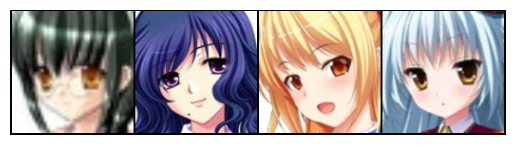

In [9]:
def show_images(dataloader):
    data_iter = iter(dataloader)
    images = next(data_iter)
    
    images = images[:4]
    
    images = images * 0.5 + 0.5
    
    grid = utils.make_grid(images, nrow=4)

    plt.imshow(grid.permute(1, 2, 0))  
    plt.axis('off')
    plt.show()

show_images(train_loader)

<p class="task" id="2"></p>

2\. Реализуйте архитектуру `DCGAN` и обучите модель. Подберите гиперпараметры таким образом, чтобы получаемые изображения стали достаточного качественными (четкими и без существенных дефектов). Во время обучения сохраняйте примеры генерации изображений из случайного шума и сравните, как менялось качество получаемых изображений в процессе обучения.

- [ ] Проверено на семинаре

In [10]:
import os
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torchvision.utils import save_image
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchsummary import summary

# Генератор
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # (z_dim, 1, 1) -> (256, 4, 4)
            nn.ConvTranspose2d(z_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            # (256, 4, 4) -> (128, 8, 8)
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            # (128, 8, 8) -> (64, 16, 16)
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Dropout(0.25),
            
            # (64, 16, 16) -> (32, 32, 32)
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            
            # (32, 32, 32) -> (16, 64, 64)
            nn.ConvTranspose2d(32, 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            
            # (16, 64, 64) -> (3, 128, 128)
            nn.ConvTranspose2d(16, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)


# Дискриминатор
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Из 8x8 в 1x1
            nn.Conv2d(512, 1, 8, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        output = self.main(input)
        output = output.view(-1) 
        return output




class DCGAN(pl.LightningModule):
    def __init__(self, z_dim=100, lr=0.0002, beta1=0.5):
        super(DCGAN, self).__init__()
        self.z_dim = z_dim
        self.generator = Generator(z_dim)
        self.discriminator = Discriminator()

        self.lr = lr
        self.beta1 = beta1
        
        self.automatic_optimization = False  # Для контролируемого обновления
        self.image_folder = "generated_images"
        os.makedirs(self.image_folder, exist_ok=True)

    def forward(self, z):
        return self.generator(z)

    def configure_optimizers(self):
        g_optimizer = torch.optim.Adam(self.generator.parameters(), lr=self.lr, betas=(self.beta1, 0.999))
        d_optimizer = torch.optim.Adam(self.discriminator.parameters(), lr=self.lr, betas=(self.beta1, 0.999))
        return [g_optimizer, d_optimizer]

    def training_step(self, batch, batch_idx):
        real_images = batch.to(self.device)

        z = torch.randn(real_images.size(0), self.z_dim, 1, 1, device=self.device)
        fake_images = self.generator(z)

        optimizers = self.optimizers()
        opt_g = optimizers[0]
        opt_d = optimizers[1]

        real_labels = torch.ones(real_images.size(0), device=self.device)
        fake_labels = torch.zeros(real_images.size(0), device=self.device)

        # Пропуск через дискриминатор
        real_output = self.discriminator(real_images)
        fake_output = self.discriminator(fake_images.detach())

        criterion = nn.BCELoss()
        real_loss = criterion(real_output, real_labels)
        fake_loss = criterion(fake_output, fake_labels)
        d_loss = (real_loss + fake_loss) / 2

        # Обновление дискриминатора
        opt_d.zero_grad()
        self.manual_backward(d_loss)
        opt_d.step()

        # Обучение генератора
        g_output = self.discriminator(fake_images)
        g_loss = criterion(g_output, real_labels)

        opt_g.zero_grad()
        self.manual_backward(g_loss)
        opt_g.step()

        self.log('d_loss', d_loss, prog_bar=True)
        self.log('g_loss', g_loss, prog_bar=True)

        return d_loss

    def on_train_epoch_end(self):
        # Сохранение изображений после каждой эпохи
        try:
            with torch.no_grad():
                fake_images = self.generator(self.fixed_noise).cpu()
                fake_images = fake_images[:4]  # Ограничиваем до 4 изображений
                os.makedirs(self.image_folder, exist_ok=True)
                save_image(fake_images, os.path.join(self.image_folder, f"epoch_{self.current_epoch}.png"), normalize=True)
                print(f"Изображение сохранено: epoch_{self.current_epoch}.png")
        except Exception as e:
            print(f"Ошибка при сохранении изображения: {e}")

    def on_fit_start(self):
        self.fixed_noise = torch.randn(64, self.z_dim, 1, 1, device=self.device)
        print("fixed_noise инициализирован")


In [11]:
model = DCGAN(z_dim=100, lr=0.005, beta1=0.5)
torch.set_float32_matmul_precision('high')
trainer = pl.Trainer(max_epochs=15)
trainer.fit(model, train_loader, test_loader)


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Python310\lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | generator     | Generator     | 1.1 M  | train
1 | discriminator | Discriminator | 2.8 M  | train
--------------------------------------------------------
3.9 M     Trainable params
0         Non-trainable params
3.9 M     Total params
15.591    Total estimated model params s

fixed_noise инициализирован
Epoch 14: 100%|██████████| 398/398 [00:53<00:00,  7.49it/s, v_num=43, d_loss=50.00, g_loss=0.000]Изображение сохранено: epoch_14.png

`Trainer.fit` stopped: `max_epochs=15` reached.



Epoch 14: 100%|██████████| 398/398 [00:53<00:00,  7.48it/s, v_num=43, d_loss=50.00, g_loss=0.000]


<p class="task" id="3"></p>

3\. Создайте наборы данных на основе архива `summer2winter_yosemite.zip`. Используя преобразования `torchvision`, приведите изображения к одному размеру и нормализуйте их. Выведите на экран несколько примеров изображений, расположив изображения из одной пары рядом по горизонтали. 

- [ ] Проверено на семинаре

<p class="task" id="4"></p>

4\. Реализуйте архитектуру `CycleGAN` и обучите модель. Подберите гиперпараметры таким образом, чтобы получаемые изображения стали достаточного качественными (четкими и без существенных дефектов). Во время обучения сохраняйте примеры преобразования (в обе стороны) и  сравните, как менялось качество получаемых изображений в процессе обучения.

- [ ] Проверено на семинаре

## Обратная связь
- [ ] Хочу получить обратную связь по решению